# SR3 RV Lab — the league table

One row per (framework, variant), built by the framework notebooks into
`notebooks/data/sfr_rv_lab/league_table.csv` through the same `league_row`
helper, so the numbers are comparable by construction.

**How to read it.** Sort by `net_bp_taker`, not by `total_net_bp`: the taker
column is the same trades charged the full 2.5bp round trip. Then check three
things before believing any row:

1. `grid_median_net_bp` — the median config of that framework's own sweep. A
   row whose best config is positive while its median is deeply negative is a
   lucky corner, not an edge.
2. `dsr_prob` — the deflated Sharpe probability, which charges the row for how
   many configs were tried. Below 0.5 means the result does not beat what the
   best of N random configs would produce under the null.
3. `n_trades` and `avg_hold_days` — a handful of long holds is one macro bet.

**Dollars.** Every P&L is in bp of package premium; SR3 is $25 per contract per
bp. The `total_net_usd` column assumes **100 packages**, and a package's own
contract count differs by framework (a 4-leg risk reversal is 4 contracts; a
digital scaled to one unit of probability is 24–32). The framework notebooks
print the exact contract count per package in their header block.

**Verdict taxonomy.** `ALIVE` = positive at taker costs, DSR probability above
0.5, and a non-negative median config. `MARGINAL-maker-only` = positive at zero
cost but not at taker. `DEAD` = everything else.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sfr_rv_lab_common import LEAGUE_CSV, DATA_DIR

pd.set_option("display.width", 260)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 200)

league = pd.read_csv(LEAGUE_CSV)
print(f"{len(league)} rows from {league['framework'].nunique()} frameworks")

47 rows from 23 frameworks


## Structural findings — what the data says can never be a trade

These are not strategy results; they are the constraints every framework in
the lab had to be built around, measured on the real panel.

In [2]:
from RVUtils.SFRRVLab import load_panels, parity_residuals   # noqa: E402

_p = load_panels(DATA_DIR)
if "quotes" in _p and "contracts" in _p:
    par = parity_residuals(_p["quotes"], _p["contracts"])["parity_bp"].abs()
    print(f"1. PUT-CALL PARITY holds to a quarter-tick: {len(par)} two-sided "
          f"strike-days, median |C - P - (F - K)| = {par.median():.3f}bp, "
          f"max {par.max():.3f}bp.")
    print("   => each surface's risk-neutral MEAN is pinned to its own futures "
          "settle. There is no mean-level RV and no conversion/reversal basis.")

_lc = DATA_DIR / "level_constraint_check.csv"
if _lc.exists():
    lc = pd.read_csv(_lc)
    print(f"\n2. The DIGITAL-CALENDAR LEVEL is pinned by the linear market: "
          f"corr(int listed digital calendar dK, futures calendar spread) = "
          f"{lc['integral_bp'].corr(lc['futures_spread_bp']):.3f} "
          f"over {len(lc)} checks; median |gap| "
          f"{lc['gap_bp'].abs().median():.2f}bp (strike-ladder truncation).")
    print("   => only the SHAPE of that profile across strikes is free.")

_lg = DATA_DIR / "lattice_gap.csv"
if _lg.exists():
    lg = pd.read_csv(_lg)
    print("\n3. OPTIONS PRICE FAR MORE TAIL than the curve-only FedWatch "
          "lattice:")
    print(lg.round(3).to_string(index=False))
    print("   => the gap is large and persistent (a premium), and where the "
          "null is near-degenerate the 'gap' signal is just the listed digital.")

1. PUT-CALL PARITY holds to a quarter-tick: 195286 two-sided strike-days, median |C - P - (F - K)| = 0.000bp, max 0.250bp.
   => each surface's risk-neutral MEAN is pinned to its own futures settle. There is no mean-level RV and no conversion/reversal basis.

2. The DIGITAL-CALENDAR LEVEL is pinned by the linear market: corr(int listed digital calendar dK, futures calendar spread) = 0.996 over 147 checks; median |gap| 0.50bp (strike-ladder truncation).
   => only the SHAPE of that profile across strikes is free.

3. OPTIONS PRICE FAR MORE TAIL than the curve-only FedWatch lattice:
 offset_bp  mean_listed  mean_null  mean_gap  sd_gap  sd_listed  sd_null    n
     -25.0        0.687      0.856    -0.169   0.080      0.089    0.092 3698
       0.0        0.540      0.541    -0.000   0.153      0.068    0.144 3673
      25.0        0.360      0.148     0.213   0.102      0.099    0.093 3739
   => the gap is large and persistent (a premium), and where the null is near-degenerate the 'gap' s

## The table, sorted honestly

In [3]:
COLS = ["framework", "variant", "class", "n_trades", "hit_rate", "avg_net_bp",
        "total_gross_bp", "net_bp_maker", "net_bp_taker", "net_usd_taker",
        "sharpe", "max_dd_bp", "max_dd_usd", "avg_hold_days", "dsr_prob",
        "grid_median_net_bp", "nonoverlap_sharpe", "verdict"]
tbl = league[[c for c in COLS if c in league.columns]].copy()
tbl = tbl.sort_values("net_bp_taker", ascending=False).reset_index(drop=True)
print(tbl.round(3).to_string(index=False))

                                   framework               variant  class  n_trades  hit_rate  avg_net_bp  total_gross_bp  net_bp_maker  net_bp_taker  net_usd_taker  sharpe  max_dd_bp   max_dd_usd  avg_hold_days  dsr_prob  grid_median_net_bp  nonoverlap_sharpe               verdict
              2c. Digital-calendar shape fly           best-config      B       168     0.542       1.940         746.000       746.000       326.000      815000.00   0.624   -239.500  -598750.000          9.845     0.015            -435.500             -0.218    SELECTION-ARTIFACT
                   6a. Fly vs belly straddle           best-config    A/C        61     0.590       4.768         443.322       443.322       290.822      727054.50   0.388   -275.167  -687917.950         17.475     0.050            -228.285              0.284    SELECTION-ARTIFACT
                   9a. Mid-curve forward vol           best-config      B         6     0.833      43.821         286.927       286.927       271.927  

## Verdict summary

In [4]:
print(league["verdict"].value_counts().to_string())
print("\nby RV class:")
print(league.groupby("class")["verdict"].value_counts().to_string())

verdict
MARGINAL-maker-only      21
DEAD                     13
DEAD (too few trades)     8
SELECTION-ARTIFACT        5

by RV class:
class   verdict              
A       MARGINAL-maker-only      7
        DEAD                     2
        SELECTION-ARTIFACT       1
A/B     DEAD                     2
        MARGINAL-maker-only      2
        DEAD (too few trades)    1
        SELECTION-ARTIFACT       1
A/C     DEAD                     1
        SELECTION-ARTIFACT       1
B       DEAD (too few trades)    6
        MARGINAL-maker-only      2
        DEAD                     1
        SELECTION-ARTIFACT       1
C       MARGINAL-maker-only      6
        DEAD                     5
        SELECTION-ARTIFACT       1
D       DEAD                     1
        DEAD (too few trades)    1
D/B     MARGINAL-maker-only      3
        DEAD                     1
linear  MARGINAL-maker-only      1


In [5]:
alive = tbl[tbl["verdict"] == "ALIVE"]
marginal = tbl[tbl["verdict"] == "MARGINAL-maker-only"]
artifact = tbl[tbl["verdict"] == "SELECTION-ARTIFACT"]
dead = tbl[tbl["verdict"].str.startswith("DEAD")]
print(f"ALIVE: {len(alive)}   SELECTION-ARTIFACT: {len(artifact)}   "
      f"MARGINAL-maker-only: {len(marginal)}   DEAD: {len(dead)}")
if len(artifact):
    print("\nProfitable at taker costs but failing deflation or the median "
          "config — i.e. the search, not the spread, is the problem:")
    print(artifact[["framework", "variant", "net_bp_taker", "dsr_prob",
                    "grid_median_net_bp", "n_trades"]]
          .round(3).to_string(index=False))
if len(alive):
    print("\nSurvivors at taker costs:")
    print(alive[["framework", "variant", "net_bp_taker", "net_usd_taker",
                 "sharpe", "dsr_prob", "grid_median_net_bp", "n_trades"]]
          .round(3).to_string(index=False))
else:
    print("\nNothing clears taker costs with a positive median config and "
          "DSR > 0.5. The ranking below is of near-misses.")

ALIVE: 0   SELECTION-ARTIFACT: 5   MARGINAL-maker-only: 21   DEAD: 21

Profitable at taker costs but failing deflation or the median config — i.e. the search, not the spread, is the problem:
                     framework     variant  net_bp_taker  dsr_prob  grid_median_net_bp  n_trades
2c. Digital-calendar shape fly best-config       326.000     0.015            -435.500       168
     6a. Fly vs belly straddle best-config       290.822     0.050            -228.285        61
        3. Gamma/theta (IV-RV) best-config        64.616     0.015            -201.420        47
     1. Skew basis (RR spread) best-config        29.500     0.000            -181.000        20
     4c. Strangle (wing level) best-config        26.373     0.000            -368.903       100

Nothing clears taker costs with a positive median config and DSR > 0.5. The ranking below is of near-misses.


## Best-config vs median-config — the selection-bias picture

Each framework's best config against the median of its own sweep. The distance
between the two dots is how much of the headline is selection.

In [6]:
best_rows = league[league["variant"].isin(["best-config", "best-variant"])]
med_rows = league[league["variant"].isin(["median-config", "median-variant"])]
cmp = (best_rows.set_index("framework")[["net_bp_taker", "grid_median_net_bp"]]
       .rename(columns={"net_bp_taker": "best_taker_bp",
                        "grid_median_net_bp": "grid_median_bp"}))
med = med_rows.set_index("framework")["net_bp_taker"].rename("median_cfg_taker_bp")
cmp = cmp.join(med).sort_values("best_taker_bp", ascending=False)
print(cmp.round(2).to_string())

                                              best_taker_bp  grid_median_bp  median_cfg_taker_bp
framework                                                                                       
2c. Digital-calendar shape fly                       326.00         -435.50                  NaN
6a. Fly vs belly straddle                            290.82         -228.28              -223.69
9a. Mid-curve forward vol                            271.93          -18.06                 2.93
9c. Mid-curve skew term structure                    116.90          -28.29               -13.68
3. Gamma/theta (IV-RV)                                64.62         -201.42              -201.79
1. Skew basis (RR spread)                             29.50         -181.00              -177.00
4c. Strangle (wing level)                             26.37         -368.90              -372.74
9b. Mid-curve coupling digitals                       -1.59           -8.78                -5.66
7. FOMC event rule (RR around 

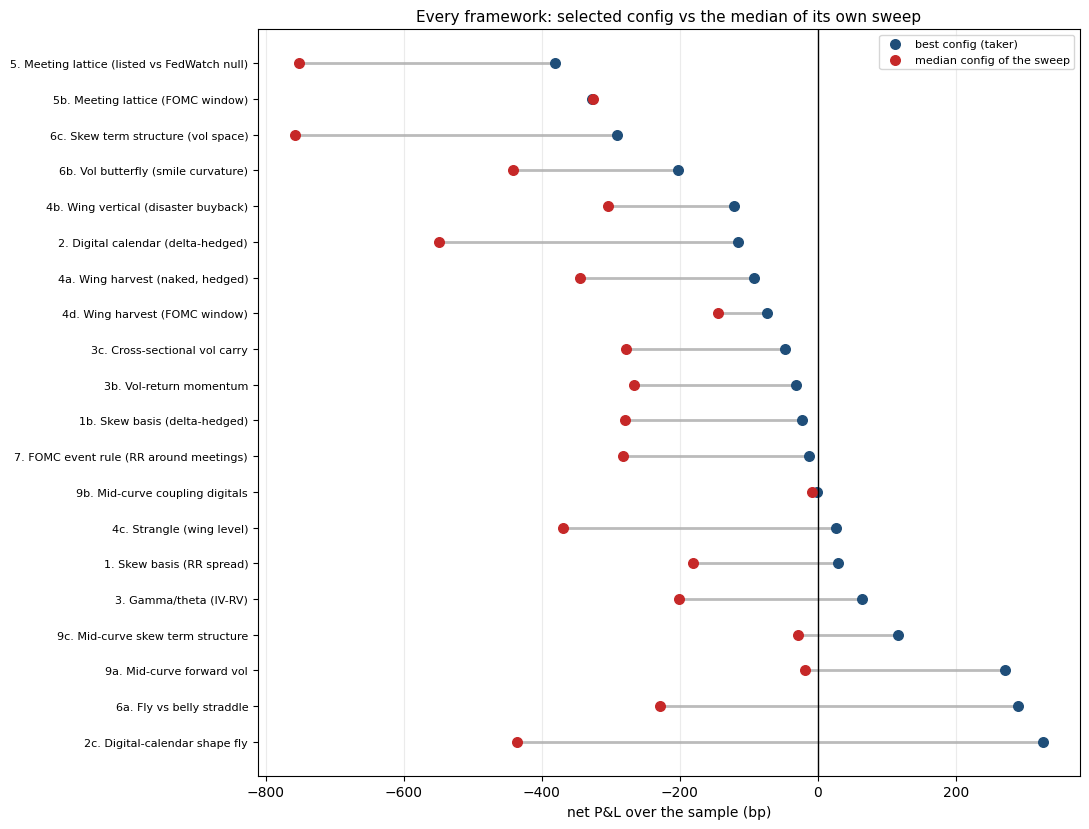

In [7]:
if len(cmp):
    fig, ax = plt.subplots(figsize=(11, max(3.5, 0.42 * len(cmp))))
    y = np.arange(len(cmp))
    ax.hlines(y, cmp["grid_median_bp"], cmp["best_taker_bp"],
              color="#bbbbbb", lw=2, zorder=1)
    ax.scatter(cmp["best_taker_bp"], y, s=48, color="#1f4e79", zorder=2,
               label="best config (taker)")
    ax.scatter(cmp["grid_median_bp"], y, s=48, color="#c62828", zorder=2,
               label="median config of the sweep")
    ax.axvline(0, color="black", lw=1)
    ax.set_yticks(y)
    ax.set_yticklabels(cmp.index, fontsize=8)
    ax.set_xlabel("net P&L over the sample (bp)")
    ax.set_title("Every framework: selected config vs the median of its own sweep",
                 fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25, axis="x")
    fig.tight_layout()
    plt.show()

## Cost sensitivity across the table

Maker (0bp) against taker (2.5bp) for every row. Frameworks whose bars cross
zero between the two are the maker-only set — real edges that the spread eats.

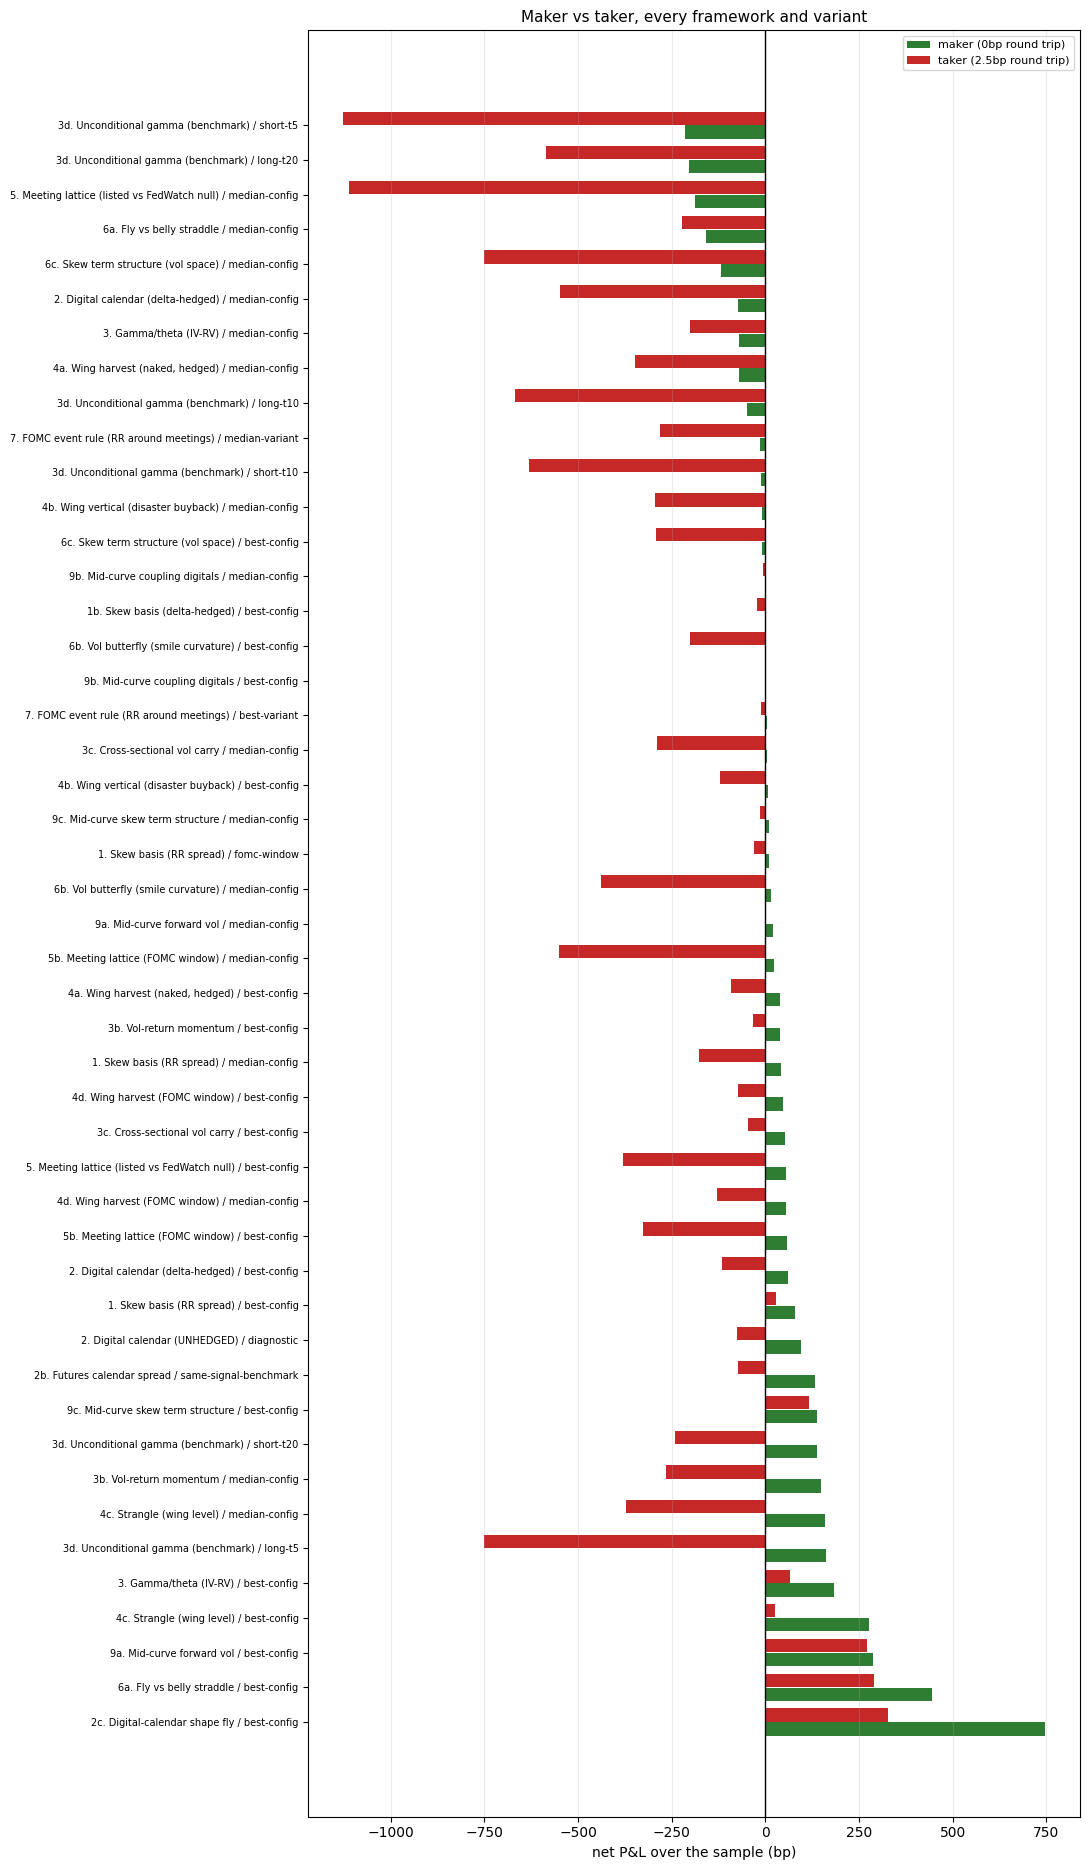

In [8]:
srt = tbl.sort_values("net_bp_maker", ascending=False)
if len(srt):
    fig, ax = plt.subplots(figsize=(11, max(3.5, 0.4 * len(srt))))
    y = np.arange(len(srt))
    ax.barh(y - 0.2, srt["net_bp_maker"], height=0.38, color="#2e7d32",
            label="maker (0bp round trip)")
    ax.barh(y + 0.2, srt["net_bp_taker"], height=0.38, color="#c62828",
            label="taker (2.5bp round trip)")
    ax.axvline(0, color="black", lw=1)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{a} / {b}" for a, b in
                        zip(srt["framework"], srt["variant"])], fontsize=7)
    ax.set_xlabel("net P&L over the sample (bp)")
    ax.set_title("Maker vs taker, every framework and variant", fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25, axis="x")
    fig.tight_layout()
    plt.show()

## Sign test across the lab

Which direction won, per framework, over the whole sweep — the house rule that
mean-reversion is never assumed.

In [9]:
sign_path = DATA_DIR / "sign_tests.csv"
if sign_path.exists():
    st = pd.read_csv(sign_path)
    print(st.round(3).to_string(index=False))
else:
    print("(per-framework sign tests are printed inside each framework notebook)")

                                   framework direction  n_configs  median_net_bp  pct_positive  best_net_bp  median_trades winning_sign
                      3. Gamma/theta (IV-RV)      fade         54       -113.638         0.167       64.616           84.0         fade
                      3. Gamma/theta (IV-RV)  momentum         54       -325.765         0.000     -116.754           84.0         fade
                     3b. Vol-return momentum      fade         54       -263.709         0.000      -31.933           95.0         fade
                     3b. Vol-return momentum  momentum         54       -269.694         0.000      -42.360           95.0         fade
               3c. Cross-sectional vol carry      fade         54       -207.104         0.000      -46.821          101.0         fade
               3c. Cross-sectional vol carry  momentum         54       -345.664         0.000      -93.810          101.0         fade
            4a. Wing harvest (naked, hedged)    

In [10]:
tbl.to_csv(DATA_DIR / "league_table_sorted.csv", index=False)
print(f"wrote {DATA_DIR / 'league_table_sorted.csv'}")

wrote C:\Users\chris\clee\ARBS\notebooks\data\sfr_rv_lab\league_table_sorted.csv
